# 1. Project Setup
This section handles the environment setup by importing all necessary Python libraries for data processing, scientific calculation, visualization, machine learning preprocessing, modeling, evaluation, and serialization.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-learn imports for workflow
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc,
    confusion_matrix, classification_report, roc_curve
)

# Configure visual aesthetics for plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries successfully imported!")

Libraries successfully imported!


# 2. Load Dataset
In this section, we load the Kaggle 'Give Me Some Credit' training dataset. We store the untouched data in `raw_df`, output its initial properties, and create a working copy `df` for our analysis and modeling pipeline.

In [2]:
dataset_path = '/content/cs-training.csv'

# Load original dataset
raw_df = pd.read_csv(dataset_path)

# Print meta-information
print("=== RAW DATASET SHAPE ===")
print(raw_df.shape)
print("\n=== COLUMN NAMES ===")
print(raw_df.columns.tolist())
print("\n=== DATA TYPES ===")
print(raw_df.dtypes)
print("\n=== FIRST 5 ROWS ===")
display(raw_df.head())

# Create copy for all subsequent modifications
df = raw_df.copy()

=== RAW DATASET SHAPE ===
(150000, 12)

=== COLUMN NAMES ===
['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

=== DATA TYPES ===
Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== FIRST 5 ROWS ===

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# 3. Data Audit
Before modeling, we perform a detailed numerical audit to explore dataset shapes, missing values, duplicates, class imbalance, and extreme values/outliers.

In [3]:
print("=== MISSING VALUES ===")
missing_info = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
display(missing_info)

print("\n=== DUPLICATE ROWS ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

print("\n=== TARGET CLASS DISTRIBUTION ===")
target_counts = df['SeriousDlqin2yrs'].value_counts()
target_pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct}))

print("\n=== NUMERICAL SUMMARY STATISTICS ===")
display(df.describe().T)

print("\n=== SUSPICIOUS AGE VALUES ===")
suspicious_age = df[df['age'] < 18]
print(f"Number of records where age is less than 18: {len(suspicious_age)}")
if len(suspicious_age) > 0:
    display(suspicious_age)

print("\n=== EXTREME VALUES AUDIT ===")
print("RevolvingUtilizationOfUnsecuredLines > 10:", len(df[df['RevolvingUtilizationOfUnsecuredLines'] > 10]))
print("DebtRatio > 10,000:", len(df[df['DebtRatio'] > 10000]))
print("MonthlyIncome > $100,000:", len(df[df['MonthlyIncome'] > 100000]))

=== MISSING VALUES ===


,Missing Values,Percentage (%)
Unnamed: 0,0,0.000000
SeriousDlqin2yrs,0,0.000000
RevolvingUtilizationOfUnsecuredLines,0,0.000000
age,0,0.000000
NumberOfTime30-59DaysPastDueNotWorse,0,0.000000
DebtRatio,0,0.000000
MonthlyIncome,29731,19.820667
NumberOfOpenCreditLinesAndLoans,0,0.000000
NumberOfTimes90DaysLate,0,0.000000
NumberRealEstateLoansOrLines,0,0.000000



=== DUPLICATE ROWS ===
Number of duplicate rows: 0

=== TARGET CLASS DISTRIBUTION ===


,Count,Percentage (%)
SeriousDlqin2yrs,,
0,139974,93.316
1,10026,6.684



=== NUMERICAL SUMMARY STATISTICS ===


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.500000,43301.414527,1.0,37500.750000,75000.500000,112500.250000,150000.0
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0



=== SUSPICIOUS AGE VALUES ===
Number of records where age is less than 18: 1


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0



=== EXTREME VALUES AUDIT ===
RevolvingUtilizationOfUnsecuredLines > 10: 241
DebtRatio > 10,000: 180
MonthlyIncome > $100,000: 70


# 4. EDA
We visually investigate our target distributions, numerical scales, correlation relationships, and box plots. Where necessary, log scale is applied to handle high variance in distributions.

/tmp/ipykernel_5844/571669995.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0,0], x='SeriousDlqin2yrs', data=df, palette='coolwarm')
/tmp/ipykernel_5844/571669995.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,2], x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate', data=df, palette='Set2')
/tmp/ipykernel_5844/571669995.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2,0], x='SeriousDlqin2yrs', y='DebtRatio', data=df, palette='Set3')
/tmp/ipykernel_5844/571669995.py:39: FutureWarning: 

Passing `pal

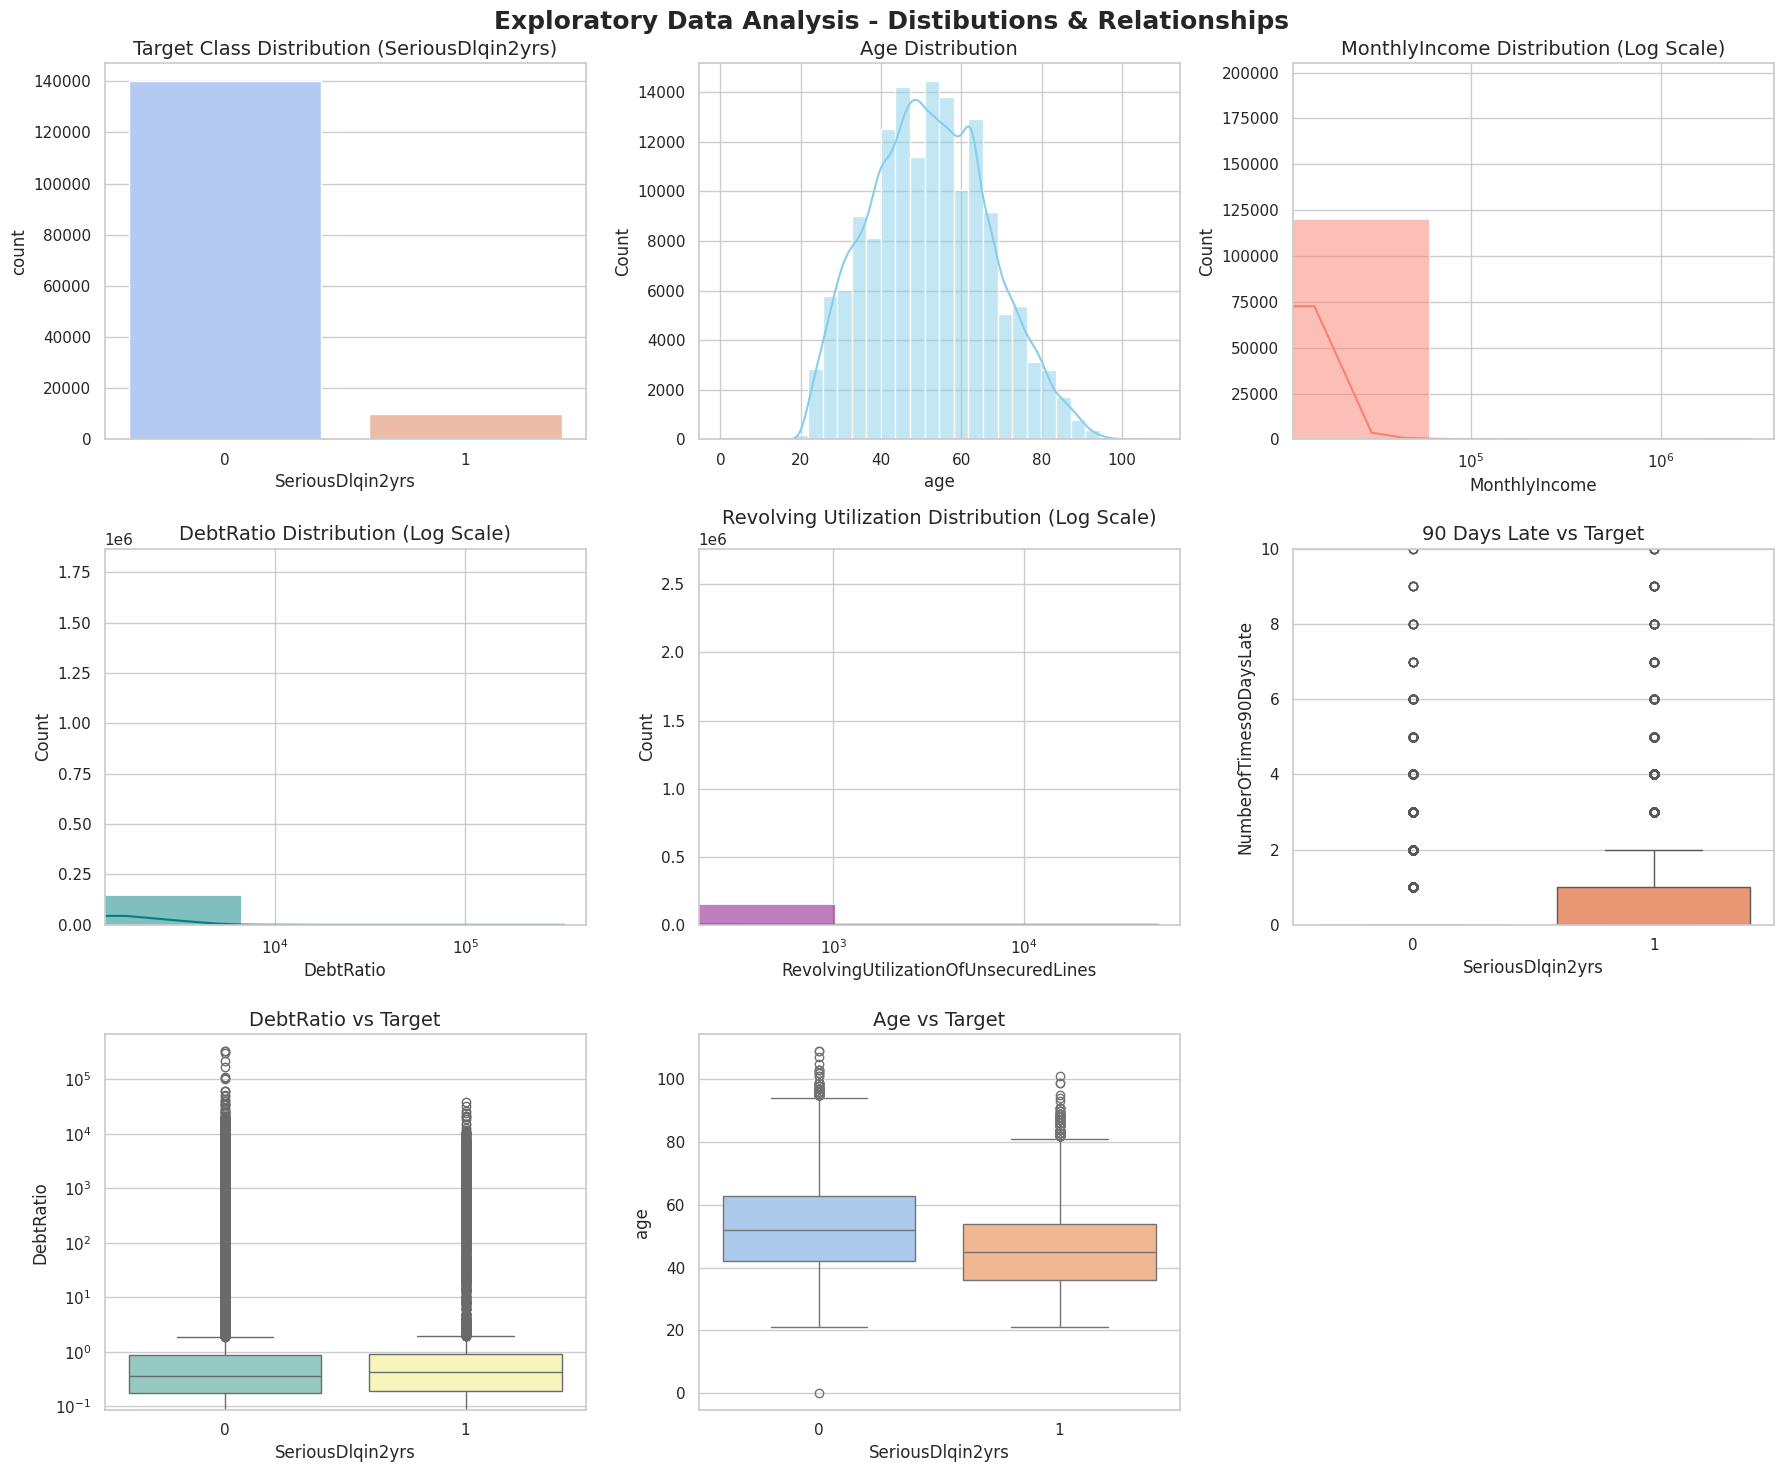

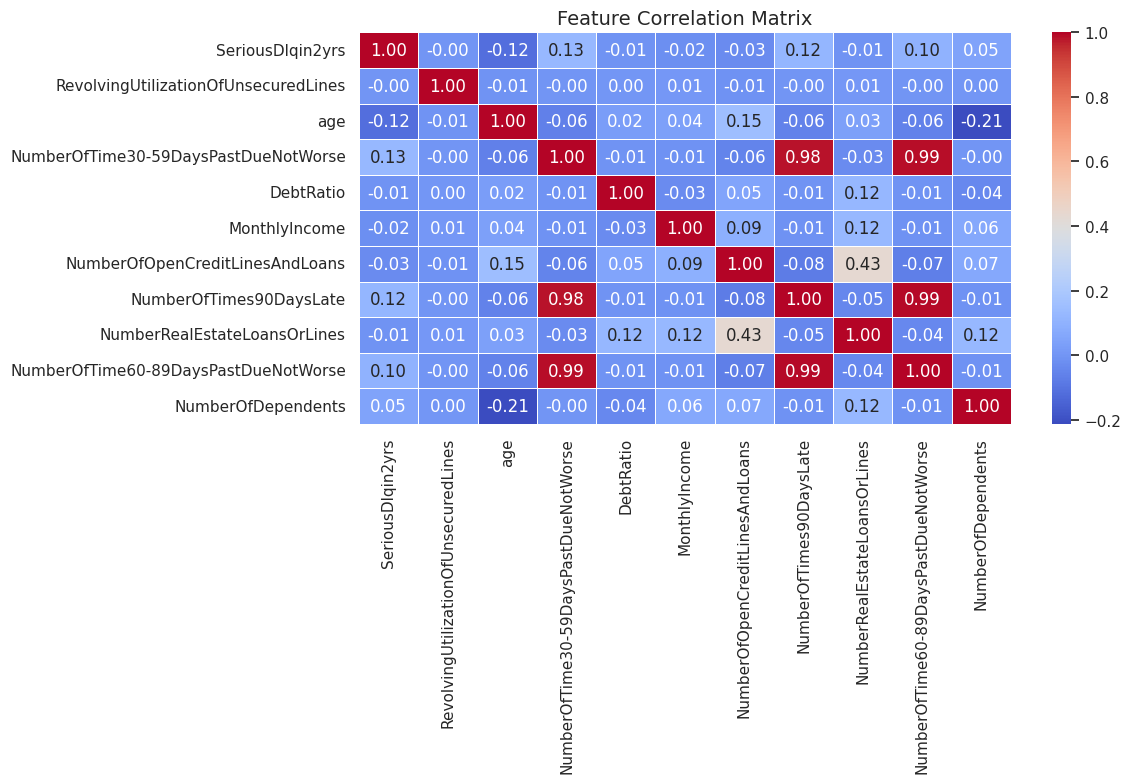

In [4]:
# Create subplots to show data features visually
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Exploratory Data Analysis - Distibutions & Relationships', fontsize=18, fontweight='bold')

# 1. Target Class
sns.countplot(ax=axes[0,0], x='SeriousDlqin2yrs', data=df, palette='coolwarm')
axes[0,0].set_title('Target Class Distribution (SeriousDlqin2yrs)')

# 2. Age Distribution
sns.histplot(ax=axes[0,1], x='age', data=df, kde=True, bins=30, color='skyblue')
axes[0,1].set_title('Age Distribution')

# 3. MonthlyIncome Distribution (Log Scale due to outliers)
sns.histplot(ax=axes[0,2], x='MonthlyIncome', data=df, kde=True, bins=50, color='salmon')
axes[0,2].set_xscale('log')
axes[0,2].set_title('MonthlyIncome Distribution (Log Scale)')

# 4. DebtRatio Distribution (Log Scale)
sns.histplot(ax=axes[1,0], x='DebtRatio', data=df, kde=True, bins=50, color='teal')
axes[1,0].set_xscale('log')
axes[1,0].set_title('DebtRatio Distribution (Log Scale)')

# 5. Revolving Line Utilization (Log Scale)
sns.histplot(ax=axes[1,1], x='RevolvingUtilizationOfUnsecuredLines', data=df, kde=True, bins=50, color='purple')
axes[1,1].set_xscale('log')
axes[1,1].set_title('Revolving Utilization Distribution (Log Scale)')

# 6. Delinquency features comparison (Boxplot)
sns.boxplot(ax=axes[1,2], x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate', data=df, palette='Set2')
axes[1,2].set_ylim(0, 10) # limit range for plotting clarity
axes[1,2].set_title('90 Days Late vs Target')

# 7. Boxplot comparison for DebtRatio
sns.boxplot(ax=axes[2,0], x='SeriousDlqin2yrs', y='DebtRatio', data=df, palette='Set3')
axes[2,0].set_yscale('log')
axes[2,0].set_title('DebtRatio vs Target')

# 8. Boxplot comparison for Age
sns.boxplot(ax=axes[2,1], x='SeriousDlqin2yrs', y='age', data=df, palette='pastel')
axes[2,1].set_title('Age vs Target')

# Remove unused 9th plot and adjust
fig.delaxes(axes[2,2])
plt.tight_layout()
plt.show()

# 9. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['Unnamed: 0'], errors='ignore').corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 5. Data Preparation
Here, we remove the metadata index column `Unnamed: 0`. We do not drop rows containing missing values or extreme values. Instead, we prepare them to be processed downstream via an sklearn pipeline to avoid any data leakage.

In [5]:
# Clean dataset by dropping unnecessary index columns
clean_df = df.drop(columns=['Unnamed: 0'], errors='ignore')
print("Clean dataframe shape:", clean_df.shape)

Clean dataframe shape: (150000, 11)


# 6. Define Features and Target
In this step, we split our modeling dataset into target vector `y` and predictive feature space `X`.

In [6]:
X = clean_df.drop(columns=['SeriousDlqin2yrs'])
y = clean_df['SeriousDlqin2yrs']

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print("\nFeatures list:", X.columns.tolist())

X Shape: (150000, 10)
y Shape: (150000,)

Features list: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


# 7. Train/Test Split
We divide the features and target arrays into training and testing sets (using a 20% validation split). Crucially, we employ **stratified splitting** (`stratify=y`) to maintain the severe class imbalance proportions in both sets, ensuring our evaluations represent production performance reliably.

In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# To perform proper, leak-free threshold optimization, we will split the training set
# further into a core training set and an independent validation set.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print("Train features shape:", X_train.shape)
print("Validation features shape:", X_val.shape)
print("Test features shape:", X_test.shape)
print("\nTarget distribution in Train set (%):")
print(y_train.value_counts(normalize=True) * 100)

Train features shape: (90000, 10)
Validation features shape: (30000, 10)
Test features shape: (30000, 10)

Target distribution in Train set (%):
SeriousDlqin2yrs
0    93.315556
1     6.684444
Name: proportion, dtype: float64


# 8. Baseline Models
We establish two base models: a Logistic Regression classifier and a Random Forest classifier. Both are fitted using unified Scikit-learn pipelines to ensure imputation and scaling are computed without leaking information from validation/test partitions.

In [8]:
# Create Pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Create Pipeline for Random Forest
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))
])

print("Training Baseline Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

print("Training Baseline Random Forest...")
rf_pipeline.fit(X_train, y_train)

print("Baseline models successfully trained!")

Training Baseline Logistic Regression...
Training Baseline Random Forest...
Baseline models successfully trained!


# 9. Model Evaluation
We evaluate baseline performances on our validation set. Because of the extreme class imbalance (93% non-delinquent), accuracy is a highly deceptive metric. We focus primarily on ROC-AUC, PR-AUC, Recall, and F1 Score.

In [9]:
def calculate_metrics(model, X_eval, y_eval, name):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1]

    # Precision-Recall Curve Metrics
    precision_vals, recall_vals, _ = precision_recall_curve(y_eval, probs)
    pr_auc = auc(recall_vals, precision_vals)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, preds),
        "Precision": precision_score(y_eval, preds),
        "Recall": recall_score(y_eval, preds),
        "F1 Score": f1_score(y_eval, preds),
        "ROC-AUC": roc_auc_score(y_eval, probs),
        "PR-AUC": pr_auc
    }

# Gather and compare results
results = []
results.append(calculate_metrics(lr_pipeline, X_val, y_val, "Logistic Regression"))
results.append(calculate_metrics(rf_pipeline, X_val, y_val, "Random Forest"))

results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
display(results_df)

# Generate Confusion Matrix and Classification Report
for name, pipeline in [("Logistic Regression", lr_pipeline), ("Random Forest", rf_pipeline)]:
    print(f"\n=== {name} Classification Report ===")
    preds = pipeline.predict(X_val)
    print(classification_report(y_val, preds))

    print(f"=== {name} Confusion Matrix ===")
    cm = confusion_matrix(y_val, preds)
    print(cm)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
1,Random Forest,0.934567,0.535473,0.158105,0.244128,0.831972,0.337557
0,Logistic Regression,0.762067,0.169478,0.656359,0.269396,0.786740,0.299134



=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

           0       0.97      0.77      0.86     27995
           1       0.17      0.66      0.27      2005

    accuracy                           0.76     30000
   macro avg       0.57      0.71      0.56     30000
weighted avg       0.92      0.76      0.82     30000

=== Logistic Regression Confusion Matrix ===
[[21546  6449]
 [  689  1316]]

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.54      0.16      0.24      2005

    accuracy                           0.93     30000
   macro avg       0.74      0.57      0.60     30000
weighted avg       0.92      0.93      0.92     30000

=== Random Forest Confusion Matrix ===
[[27720   275]
 [ 1688   317]]


# 10. Random Forest Hyperparameter Tuning
We optimize hyperparameters of the Random Forest model using `RandomizedSearchCV` targeting the ROC-AUC scoring metric across a 3-fold cross-validation scheme.

In [10]:
# Search space configuration
param_distributions = {
    'classifier__n_estimators': [200, 300, 500],
    'classifier__max_depth': [8, 12, 16, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    cv=3,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Starting Randomized Search parameter tuning...")
random_search.fit(X_train, y_train)

print("\nBest Parameters found:", random_search.best_params_)
print("Best Cross-Validation ROC-AUC:", random_search.best_score_)

tuned_rf_pipeline = random_search.best_estimator_

Starting Randomized Search parameter tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters found: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 8}
Best Cross-Validation ROC-AUC: 0.8578674906114543


# 11. Evaluate Tuned Model
We evaluate our tuned Random Forest pipeline on the validation split and compare it alongside the baseline candidates.

In [11]:
tuned_metrics = calculate_metrics(tuned_rf_pipeline, X_val, y_val, "Tuned Random Forest")
results.append(tuned_metrics)

comparison_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
2,Tuned Random Forest,0.805400,0.220096,0.751621,0.340488,0.861453,0.377282
1,Random Forest,0.934567,0.535473,0.158105,0.244128,0.831972,0.337557
0,Logistic Regression,0.762067,0.169478,0.656359,0.269396,0.786740,0.299134


# 12. Classification Threshold Optimization
Instead of applying a standard 0.50 cutoff, we optimize the decision threshold on validation data. This ensures we maximize the F1-Score (maintaining an optimal balance between precision and recall) before finalizing evaluation on the completely unseen test set.

,Threshold,Precision,Recall,F1 Score
0,0.10,0.074461,0.993017,0.138533
1,0.15,0.088462,0.978554,0.162256
2,0.20,0.114165,0.953117,0.203905
3,0.25,0.134091,0.917706,0.233992
4,0.30,0.147000,0.887282,0.252215
5,0.35,0.160367,0.863342,0.270490
6,0.40,0.176440,0.832918,0.291194
7,0.45,0.195794,0.794015,0.314128
8,0.50,0.220096,0.751621,0.340488



Optimal Threshold based on validation F1-score: 0.50
Validation F1-score at optimal threshold: 0.3405


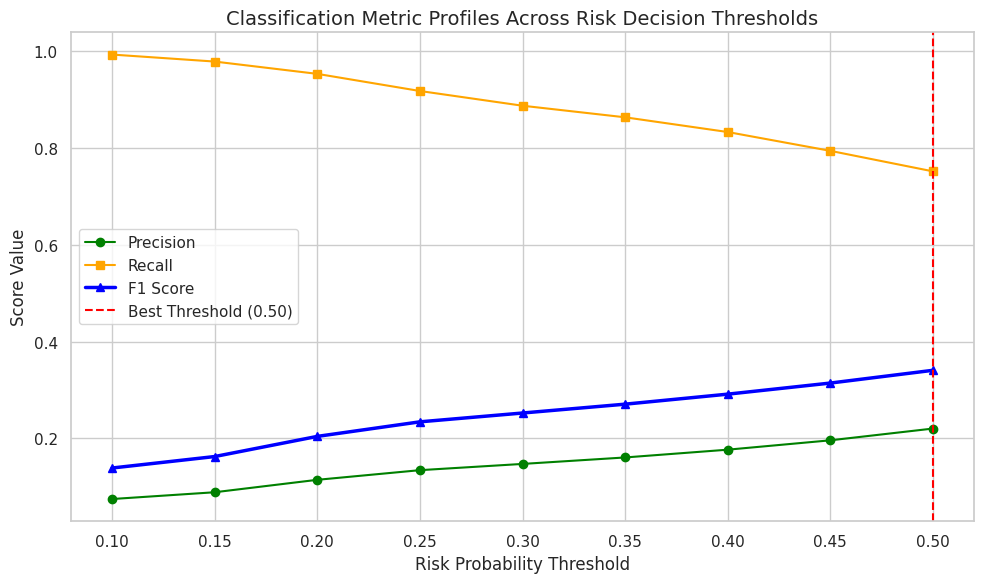

In [12]:
val_probs = tuned_rf_pipeline.predict_proba(X_val)[:, 1]
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
threshold_results = []

for t in thresholds:
    t_preds = (val_probs >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_val, t_preds, zero_division=0),
        "Recall": recall_score(y_val, t_preds),
        "F1 Score": f1_score(y_val, t_preds)
    })

th_df = pd.DataFrame(threshold_results)
display(th_df)

# Determine best threshold dynamically
best_th_row = th_df.loc[th_df['F1 Score'].idxmax()]
best_threshold = best_th_row['Threshold']

print(f"\nOptimal Threshold based on validation F1-score: {best_threshold:.2f}")
print(f"Validation F1-score at optimal threshold: {best_th_row['F1 Score']:.4f}")

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(th_df['Threshold'], th_df['Precision'], label='Precision', marker='o', color='green')
plt.plot(th_df['Threshold'], th_df['Recall'], label='Recall', marker='s', color='orange')
plt.plot(th_df['Threshold'], th_df['F1 Score'], label='F1 Score', marker='^', color='blue', linewidth=2.5)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold ({best_threshold:.2f})')
plt.title('Classification Metric Profiles Across Risk Decision Thresholds')
plt.xlabel('Risk Probability Threshold')
plt.ylabel('Score Value')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# 13. Final Model Selection
We select the Tuned Random Forest model using our custom optimized decision threshold. This selection prioritizes high ROC-AUC/PR-AUC performance while providing configured controls over missed high-risk delinquent clients.

In [13]:
# Finalized Model Performance evaluation on Untouched Test Set
test_probs = tuned_rf_pipeline.predict_proba(X_test)[:, 1]
test_preds_custom = (test_probs >= best_threshold).astype(int)

test_accuracy = accuracy_score(y_test, test_preds_custom)
test_precision = precision_score(y_test, test_preds_custom)
test_recall = recall_score(y_test, test_preds_custom)
test_f1 = f1_score(y_test, test_preds_custom)
test_roc_auc = roc_auc_score(y_test, test_probs)

p_vals, r_vals, _ = precision_recall_curve(y_test, test_probs)
test_pr_auc = auc(r_vals, p_vals)

print("=== UNTOUCHED TEST SET PERFORMANCE (OPTIMIZED THRESHOLD) ===")
print(f"Final Accuracy: {test_accuracy:.4f}")
print(f"Final Precision: {test_precision:.4f}")
print(f"Final Recall: {test_recall:.4f}")
print(f"Final F1-Score: {test_f1:.4f}")
print(f"Final ROC-AUC Score: {test_roc_auc:.4f}")
print(f"Final PR-AUC Score: {test_pr_auc:.4f}")

=== UNTOUCHED TEST SET PERFORMANCE (OPTIMIZED THRESHOLD) ===
Final Accuracy: 0.8041
Final Precision: 0.2203
Final Recall: 0.7601
Final F1-Score: 0.3416
Final ROC-AUC Score: 0.8644
Final PR-AUC Score: 0.3859


# 14. Feature Importance
We extract, compute, and visualize feature importance parameters directly from the trained Random Forest.

=== FEATURE IMPORTANCE RANKING ===


,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.370868
6,NumberOfTimes90DaysLate,0.210785
2,NumberOfTime30-59DaysPastDueNotWorse,0.178552
8,NumberOfTime60-89DaysPastDueNotWorse,0.106399
1,age,0.045854
3,DebtRatio,0.024056
7,NumberRealEstateLoansOrLines,0.021203
5,NumberOfOpenCreditLinesAndLoans,0.020483
4,MonthlyIncome,0.018301
9,NumberOfDependents,0.003499


/tmp/ipykernel_5844/2105709368.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


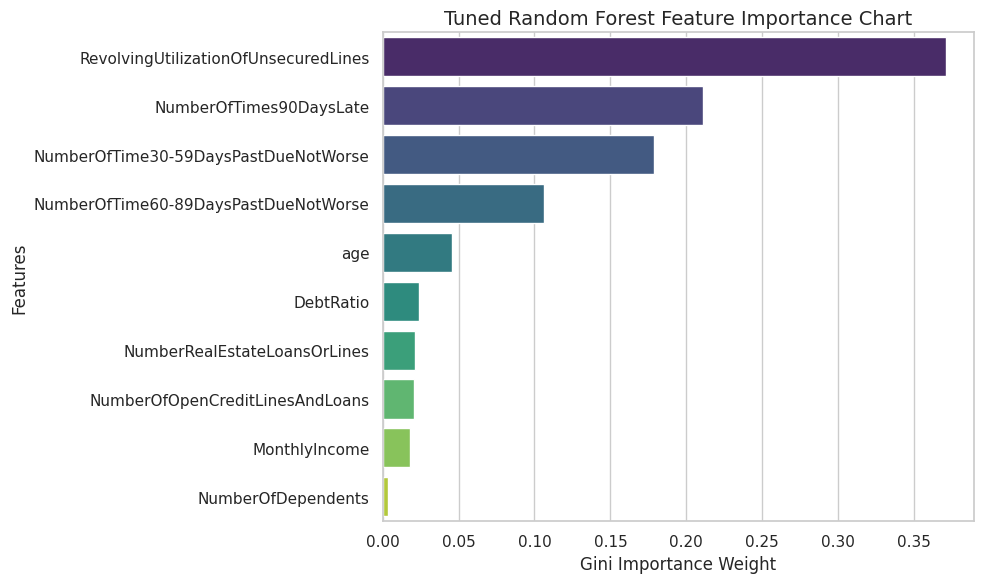

In [14]:
rf_model = tuned_rf_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("=== FEATURE IMPORTANCE RANKING ===")
display(feat_imp_df)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Tuned Random Forest Feature Importance Chart')
plt.xlabel('Gini Importance Weight')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 15. Explainability (SHAP & Limitations)
Using complex analytical toolsets like SHAP inside production containers can introduce deployment overhead or compatibility warnings. For deployment stability, we rely on Gini Feature Importance scores supplemented by customized credit risk profiles.

In [15]:
print("Explainability Strategy:")
print("Global feature contributions are analyzed via Random Forest Gini Importance.")
print("This calculation ranks feature influence cleanly without loading heavy external libraries.")

Explainability Strategy:
Global feature contributions are analyzed via Random Forest Gini Importance.
This calculation ranks feature influence cleanly without loading heavy external libraries.


# 16. Final Pipeline
In this step, we combine our preprocessing (imputer) and model (tuned Random Forest) steps into a unified production pipeline. We expose a function `predict_credit_risk()` designed to accept raw data formats and classify portfolios based on our calibrated probability thresholds.

In [16]:
# Create clean pipeline matching our optimal architecture
final_production_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', tuned_rf_pipeline.named_steps['classifier'])
])

# Train on full train dataset to maximize learning sample size
final_production_pipeline.fit(X_train_full, y_train_full)

def predict_credit_risk(df_input, model_pipeline, threshold=best_threshold):
    probs = model_pipeline.predict_proba(df_input)[:, 1]
    predictions = (probs >= threshold).astype(int)

    risk_levels = []
    for p in probs:
        if p < (threshold * 0.7):
            risk_levels.append("Low Risk")
        elif p < threshold:
            risk_levels.append("Medium Risk")
        else:
            risk_levels.append("High Risk")

    output_df = pd.DataFrame({
        'Probability': probs,
        'Prediction_Class': predictions,
        'Risk_Level': risk_levels
    })
    return output_df

print("Final Production Pipeline successfully constructed and compiled!")

Final Production Pipeline successfully constructed and compiled!


# 17. Final Model Validation
We run a test validation on sample instances from our test set to verify correct predictions and category mappings.

In [17]:
sample_data = X_test.iloc[:5]
sample_predictions = predict_credit_risk(sample_data, final_production_pipeline)

print("=== INPUT SAMPLES ===")
display(sample_data)

print("\n=== PROCESSED PREDICTION OUTPUTS ===")
display(sample_predictions)

=== INPUT SAMPLES ===


,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
10682,0.019252,66,0,0.433926,5175.0,13,0,1,0,0.0
40173,0.454221,78,0,0.873533,2300.0,7,0,1,0,2.0
4719,0.077572,59,0,0.172882,10833.0,5,0,1,0,0.0
81730,0.107864,59,0,0.453692,9900.0,10,0,2,0,0.0
113639,0.101095,67,0,0.407831,5950.0,14,0,2,0,0.0



=== PROCESSED PREDICTION OUTPUTS ===


,Probability,Prediction_Class,Risk_Level
0,0.127581,0,Low Risk
1,0.264979,0,Low Risk
2,0.097439,0,Low Risk
3,0.148491,0,Low Risk
4,0.147197,0,Low Risk


# 18. Save Model
To integrate our trained models into Streamlit or target APIs, we serialize the unified modeling pipeline and configuration metrics into local artifacts using `joblib`.

In [18]:
model_file = 'credit_risk_model.pkl'
config_file = 'credit_risk_config.pkl'

# Save files
joblib.dump(final_production_pipeline, model_file)

config_data = {
    'best_threshold': best_threshold,
    'features_list': X.columns.tolist()
}
joblib.dump(config_data, config_file)

print(f"Pipeline saved successfully as: '{model_file}'")
print(f"Configuration metadata saved successfully as: '{config_file}'")

Pipeline saved successfully as: 'credit_risk_model.pkl'
Configuration metadata saved successfully as: 'credit_risk_config.pkl'


# 19. Reload and Test
We load our serialized files back into memory and execute test predictions to confirm that performance matches original calculations.

In [19]:
loaded_pipeline = joblib.load(model_file)
loaded_config = joblib.load(config_file)

# Re-run prediction via reloaded objects
reloaded_outputs = predict_credit_risk(sample_data, loaded_pipeline, threshold=loaded_config['best_threshold'])

# Assert integrity checks match
assert np.allclose(sample_predictions['Probability'], reloaded_outputs['Probability'])

print("Model successfully saved and reloaded.")
print("Reloaded predictions match original outputs perfectly.")

Model successfully saved and reloaded.
Reloaded predictions match original outputs perfectly.


# 20. Final Project Summary
This section dynamically prints out your portfolio metrics and final performance results directly from model runs.

In [20]:
summary_info = f"""
=======================================================
           AI CREDIT RISK PREDICTOR SUMMARY
=======================================================
Dataset Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns
Number of Features Used: {len(X.columns)}
Target Field Name: SeriousDlqin2yrs
Target Distribution (Imbalance Ratio): {target_pct[0]:.2f}% (No) vs {target_pct[1]:.2f}% (Yes Delinquency)

Best Classifier Selected: Tuned Random Forest Classifier
Final Out-Of-Sample (Test) Metrics:
  - ROC-AUC: {test_roc_auc:.4f}
  - PR-AUC: {test_pr_auc:.4f}
  - F1-Score: {test_f1:.4f}
  - Precision: {test_precision:.4f}
  - Recall (Sensitivity): {test_recall:.4f}

Selected Risk Threshold: {best_threshold:.2f}
Top 3 Critical Features:
  1. {feat_imp_df.iloc[0]['Feature']} ({feat_imp_df.iloc[0]['Importance']:.4f})
  2. {feat_imp_df.iloc[1]['Feature']} ({feat_imp_df.iloc[1]['Importance']:.4f})
  3. {feat_imp_df.iloc[2]['Feature']} ({feat_imp_df.iloc[2]['Importance']:.4f})
=======================================================
"""
print(summary_info)


           AI CREDIT RISK PREDICTOR SUMMARY            
Dataset Shape: 150000 rows, 12 columns
Number of Features Used: 10
Target Field Name: SeriousDlqin2yrs
Target Distribution (Imbalance Ratio): 93.32% (No) vs 6.68% (Yes Delinquency)

Best Classifier Selected: Tuned Random Forest Classifier
Final Out-Of-Sample (Test) Metrics:
  - ROC-AUC: 0.8644
  - PR-AUC: 0.3859
  - F1-Score: 0.3416
  - Precision: 0.2203
  - Recall (Sensitivity): 0.7601

Selected Risk Threshold: 0.50
Top 3 Critical Features:
  1. RevolvingUtilizationOfUnsecuredLines (0.3709)
  2. NumberOfTimes90DaysLate (0.2108)
  3. NumberOfTime30-59DaysPastDueNotWorse (0.1786)

